# Projeto de Análise Churn

### Contexto

O produto principal da empresa é um sistema de ERP (Enterprise Resource Planning), um tipo de software utilizado por pequenas e médias empresas para gerenciar rotinas administrativas, como emissão de notas fiscais, controle de estoque, financeiro, entre outras.

Nos últimos meses, alguns colaboradores levantaram a hipótese de que a taxa de churn (cancelamento de assinaturas) da plataforma estaria aumentando.

O objetivo deste projeto é validar a hipótese de aumento na taxa de churn da plataforma, por meio de uma análise exploratória dos dados que permita identificar padrões, comportamentos e informações relevantes sobre os clientes, gerando insights que possam apoiar a equipe de negócios na tomada de decisão.

### Perguntas Norteadoras
1. A taxa de churn realmente aumentou ao longo do tempo? Há tendência de crescimento ao longo do tempo?
2. Existe relação entre o tipo de contrato e o churn?
3. Características da empresa, como tipo, ano de fundação, possui mais de um sócio e número de funcionários, estão associadas ao churn?
4. O churn varia conforme o tempo de relacionamento com a empresa?
5. O uso de funcionalidades do sistema está relacionado ao churn?

# Importando bibliotecas e lendo arquivo csv

In [45]:
#Importando Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [46]:
#Lendo o arquivo csv
df = pd.read_csv("customer_churn_with_months.csv")

In [47]:
#Conferindo a importação do arquivo
df.head()

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
0,1,Micro empresa,2016,Sim,até 5 funcionários,1,Não,NaN,automática,Pouco uso,...,Pouco uso,Pouco uso,Mês-a-mês,1,Yes,Boleto - pagamento único,29.85,29.85,Não,NaN
1,2,Pequena empresa,2018,Não,até 5 funcionários,34,Sim,Não,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Boleto - mês a mês,56.95,1889.50,Não,NaN
2,4,Pequena empresa,2016,Não,até 5 funcionários,45,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Cartão de crédito - pagamento único,42.30,1840.75,Não,NaN
3,7,Pequena empresa,2019,Não,6 ou mais funcionários,22,Sim,Sim,manual,Pouco uso,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Cartão de crédito - mês a mês,89.10,1949.40,Não,NaN
4,8,Micro empresa,2019,Não,até 5 funcionários,10,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Mês-a-mês,0,No,Boleto - mês a mês,29.75,301.90,Não,NaN


## Dicionário de Variáveis

| Variável                                                        | Descrição                                                                                 |
|------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **ID**                                                           | Identificador único para cada cliente.                                                   |
| **Tipo de empresa**                                              | Categoria da empresa, como MEI, ME, EPP, etc.                                            |
| **Fundação da empresa**                                          | Ano de fundação da empresa.                                                              |
| **Possui mais de um sócio**                                      | Indica se a empresa possui mais de um sócio (Sim/Não).                                   |
| **Funcionários**                                                 | Número de funcionários na empresa ou faixa categorizada.                                 |
| **Meses de permanência**                                         | Quantidade de meses desde o início do contrato até maio de 2025.                         |
| **Utiliza serviços financeiros**                                 | Indica se a empresa utiliza serviços financeiros (Sim/Não).                              |
| **PossuiContador**                                               | Indica se a empresa possui contador (Sim/Não).                                           |
| **Faz conciliação bancária**                                     | Indica se a empresa realiza conciliação bancária (manual ou automática).                 |
| **Frequência: Módulo financeiro**                                | Frequência de utilização do módulo financeiro do sistema (ex: Pouco uso, Uso frequente). |
| **Frequência: Emissão de nota fiscal**                           | Frequência de utilização da emissão de nota fiscal no sistema.                           |
| **Frequência: Integração bancária**                              | Frequência de utilização da integração bancária no sistema.                              |
| **Frequência: Módulo de vendas**                                 | Frequência de utilização do módulo de vendas no sistema.                                 |
| **Frequência: Relatórios**                                       | Frequência de utilização de relatórios no sistema.                                       |
| **Frequência: APIs de integração**                               | Frequência de utilização de APIs de integração no sistema.                               |
| **Contrato**                                                     | Tipo de contrato com o cliente (ex: Mês-a-mês, Trimestral, Anual).                       |
| **Emite boletos**                                                | Indica se a empresa emite boletos (1/0).                                       |
| **Emite boletos.1**                                              | Indica se a empresa emite boleto (Yes/No)                                                |
| **Tipo de pagamento**                                            | Método de pagamento utilizado pelo cliente.                                              |
| **Receita mensal**                                               | Receita mensal gerada pelo cliente.                                                      |
| **Receita total**                                                | Receita total acumulada pelo cliente ao longo da permanência.                            |
| **Churn**                                                        | Indica se houve churn (cancelamento) do cliente (Sim/Não).                               |
| **mes_churn**                                                  | Indica que mês houve o churn.                                                   |

 # 1. Análise Univariada

### 1.1 Informações do DataFrame

In [48]:
df.shape

(7043, 23)

- Data frame possui 7043 linhas e 23 colunas.

In [49]:
df.columns

Index(['ID', 'Tipo de empresa', 'Fundação da empresa',
       'Possui mais de um sócio', 'Funcionários', 'Meses de permanência ',
       'Utiliza serviços financeiros', 'PossuiContador',
       'Faz conciliação bancária',
       'Frequência de utilização de feature do sistema: Módulo financeiro',
       'Frequência de utilização de feature do sistema: Emissão de nota fiscal',
       'Frequência de utilização de feature do sistema: Integração bancária',
       'Frequência de utilização de feature do sistema: Módulo de vendas',
       'Frequência de utilização de feature do sistema: Relatórios',
       'Frequência de utilização de feature do sistema: Utilização de APIs de integração',
       'Contrato', 'Emite boletos', 'Emite boletos.1', 'Tipo de pagamento',
       'Receita mensal', 'Receita total', 'Churn', 'mes_churn'],
      dtype='str')

In [50]:
# Visão geral dos tipos de dados e valores nulos
overview = pd.DataFrame({
    "Tipo": df.dtypes,
    "Nulos": df.isnull().sum(),
    "% Nulos": df.isnull().mean()*100,
    "Valores Únicos": df.nunique(),
    "Exemplo de Valores": df.apply(lambda x: x.unique()[:3])
})
overview

,Tipo,Nulos,% Nulos,Valores Únicos,Exemplo de Valores
ID,int64,0,0.000000,7043,"[1, 2, 4]"
Tipo de empresa,str,0,0.000000,2,"[Micro empresa, Pequena empresa]"
Fundação da empresa,int64,0,0.000000,21,"[2016, 2018, 2019]"
Possui mais de um sócio,str,0,0.000000,2,"[Sim, Não]"
Funcionários,str,0,0.000000,2,"[até 5 funcionários, 6 ou mais funcionários]"
Meses de permanência,int64,0,0.000000,73,"[1, 34, 45]"
Utiliza serviços financeiros,str,0,0.000000,2,"[Não, Sim]"
PossuiContador,str,682,9.683374,2,"[nan, Não , Sim]"
Faz conciliação bancária,str,0,0.000000,3,"[automática, manual, não faz]"
Frequência de utilização de feature do sistema: Módulo financeiro,str,0,0.000000,3,"[Pouco uso, Uso frequente, Nunca utilizou]"


- Colunas duplicadas para “Emite boletos” (Emite boletos e Emite boletos.1), uma como inteiro (0/1), outra como texto (“Yes”/“No”).
- Valores “nan”, nulos, ou vazios em colunas como PossuiContador, Receita total e mes_churn.
- Coluna Emite boletos.1 tem valores "Yes" e "No" enquanto o resto usa "Sim" e "Não".


Agora vamos analisar uma variável de cada vez e:
* Detectar problemas, se houverem
* Mostrar estatísticas relevantes
* Fazer uma breve análise sobre qualidade e utilidade

### 1.2 Tipo empresa

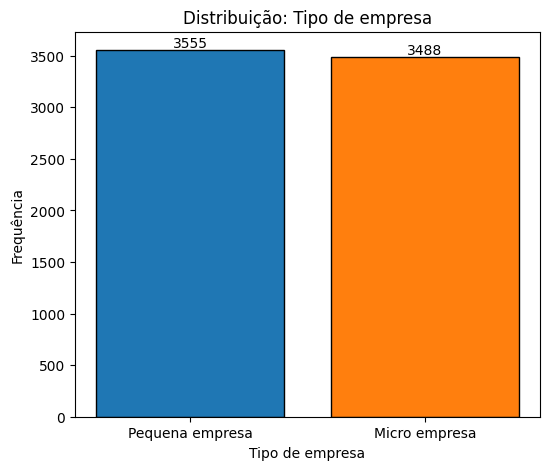

-->Tipo de dados:
str

-->Valores únicos:
2 valores distintos
<StringArray>
['Micro empresa', 'Pequena empresa']
Length: 2, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Tipo de empresa
Pequena empresa    3555
Micro empresa      3488
Name: count, dtype: int64

-->Frequência relativa(%):
Tipo de empresa
Pequena empresa    50.47565
Micro empresa      49.52435
Name: proportion, dtype: float64


In [51]:
#Análise da coluna "Tipo de Empresa"

col = "Tipo de empresa"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Tipo de Empresa" representa a categoria da empresa. Ela é categórica nominal, formatada como texto.

Existem 2 categorias distintas: Pequena empresa e Micro empresa. Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é bem equilibrada, sendo 50,47% dos registros pertencentes à categoria de Pequena empresa e 49,52% à de Micro empresa.

Do ponto de vista analítico, essa variável possui potencial de segmentação. Também faz sentido cruzar essa variável com Churn, visto que o porte da empresa, por motivos como estrutura e sensibilidade ao preço.

### 1.3 Fundação da empresa

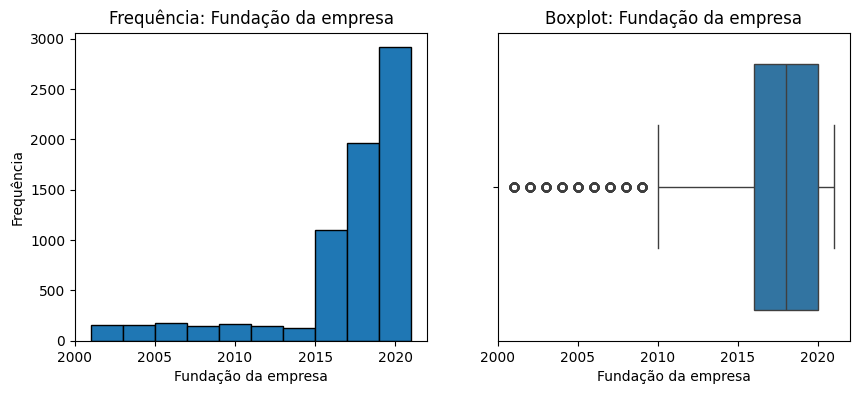

-->Tipo de dados:
int64

-->Valores únicos:
21 valores distintos
[2016 2018 2019 2021 2017 2008 2005 2020 2004 2011 2007 2001 2009 2013
 2012 2014 2006 2015 2003 2002 2010]

-->Valores nulos:
0
0.0% do total

-->Estatisticas descritivas:
count    7043.000000
mean     2016.736476
std         4.582311
min      2001.000000
25%      2016.000000
50%      2018.000000
75%      2020.000000
max      2021.000000
Name: Fundação da empresa, dtype: float64




In [52]:
#Análise da coluna "Fundação da empresa"

col = "Fundação da empresa"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
#% de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Estatisticas descritivas
estatisticas_descritivas = df[col].describe()

#Gráficos
plt.figure(figsize=(10,4))

#Histograma
plt.subplot(1,2,1)
grafico_hist = plt.hist(df[col], ec='k')
plt.title(f'Frequência: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")

#Boxplot
plt.subplot(1,2,2)
grafico_box = sns.boxplot(x=col, data=df)
plt.title(f'Boxplot: {col}')
plt.xlabel(col)
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Estatisticas descritivas:\n{estatisticas_descritivas}\n\n")


A variável "Fundação da empresa" representa o ano em que a empresa foi fundada. Trata-se de uma variável numérica discreta, registrada como int, sem nenhum valore ausente.

Estatísticas descritivas:

- Média: 2016,73
- Mediana: 2018
- Desvio Padrão: 4,58
- Valor Mínimo: 2001
- Valor Máximo: 2021

A distribuição é assimétrica positiva, observada por meio dos gráficos, com presença de outliers, que não impactam a análise.

Em termos de qualidade, não há necessidade de tratamento adicional. 

Possível agrupamento identificado, visto que os anos podem ser agrupados em diferentes faixas.

Essa variável pode ser usada em cruzamentos com o Churn, pois empresas mais antigas podem representar menor taxa de churn devido ao fato de terem maior estabilidade operacional.

### 1.4 Possui mais de um sócio

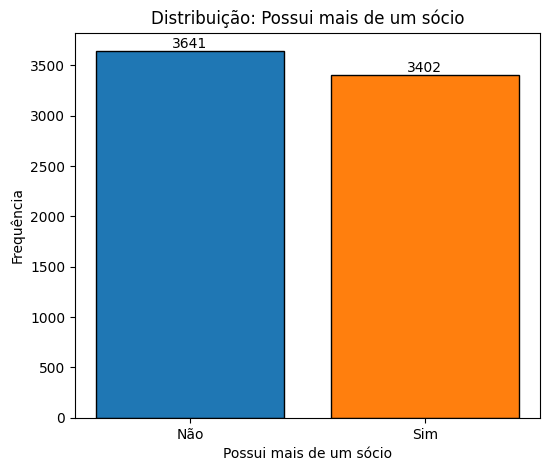

-->Tipo de dados:
str

-->Valores únicos:
2 valores distintos
<StringArray>
['Sim', 'Não']
Length: 2, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Possui mais de um sócio
Não    3641
Sim    3402
Name: count, dtype: int64

-->Frequência relativa(%):
Possui mais de um sócio
Não    51.69672
Sim    48.30328
Name: proportion, dtype: float64


In [53]:
#Análise da coluna "Possui mais de um sócio"
col = "Possui mais de um sócio"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Possui mais de um sócio" representa se a empresa tem um mais de um sócio. Ela é categórica booleana, formatada como texto.

Existem 2 categorias distintas: Sim e Não. Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é bem equilibrada, sendo 51,69% dos registros "Sim" e 48,30% "Não".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, pois a presença de mais de um sócio pode impactar a tomada de decisão, fazendo com que sejam tanto mais estruturadas quanto mais propensa a divergências.

### 1.5 Funcionários

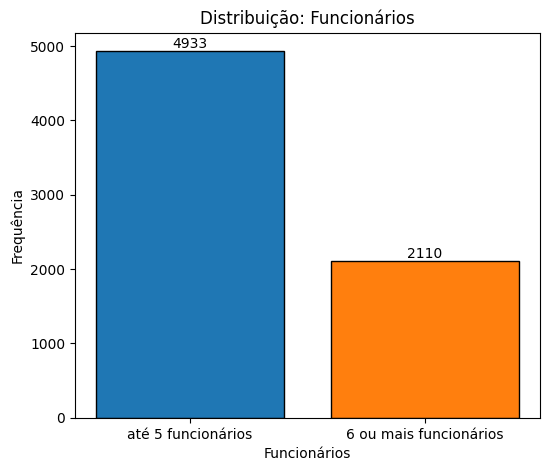

-->Tipo de dados:
str

-->Valores únicos:
2 valores distintos
<StringArray>
['até 5 funcionários', '6 ou mais funcionários']
Length: 2, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Funcionários
até 5 funcionários        4933
6 ou mais funcionários    2110
Name: count, dtype: int64

-->Frequência relativa(%):
Funcionários
até 5 funcionários        70.041176
6 ou mais funcionários    29.958824
Name: proportion, dtype: float64


In [54]:
#Análise da coluna "Funcionários"

col = "Funcionários"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Funcionários" representa quantos funcionários a empresa tem, separada em duas categorias. Ela é categórica nominal, formatada como texto.

Existem 2 categorias distintas: 'até 5 funcionários' e '6 ou mais funcionários'. Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias desbalanceada, 70% das empresas possuem até 5 funcionários e 29,9% 6 ou mais.

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, pois empresas com mais funcionários tendem a apresentar menor churn, o que pode estar associado a maior estrutura operacional. Tornando viável também o cruzamento dessa variável com o tipo de empresa para entendermos a relação do número de funcionários e o porte dela.

### 1.6 Meses de permanência

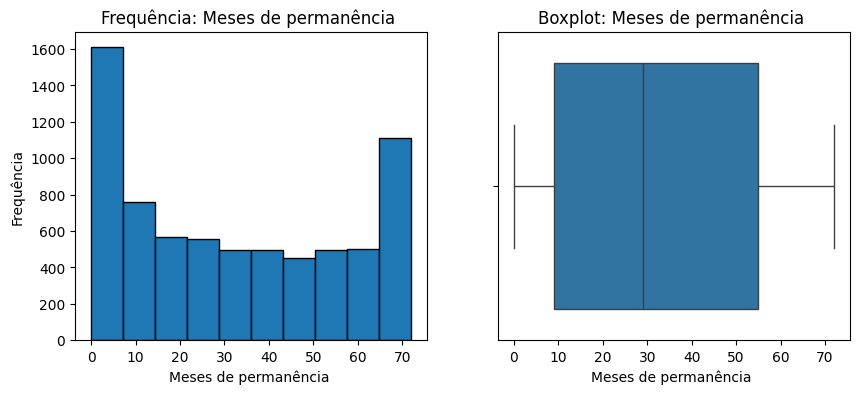

-->Tipo de dados:
int64

-->Valores únicos:
73 valores distintos
[ 1 34 45 22 10 62 13 16 58 25 69 52 71 21 12 49 30 72  2 27 46 70 17 63
 43 60 66 47 18  3 31 50 64 56  8 11 42  9 35 48 29 65 38  5 32 36 41  6
  7  4 33 67 23 57 61 15 14 53 20 40 59 24 44 54 51 19 68 28 37 55 26  0
 39]

-->Valores nulos:
0
0.0% do total

-->Estatisticas descritivas:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Meses de permanência , dtype: float64




In [55]:
#Análise da coluna "Meses de permanência " 

col = "Meses de permanência "

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Estatisticas descritivas
estatisticas_descritivas = df[col].describe()

#Gráficos
plt.figure(figsize=(10,4))

#Histograma
plt.subplot(1,2,1)
grafico_hist = plt.hist(df[col], ec='k')
plt.title(f'Frequência: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")

#Boxplot
plt.subplot(1,2,2)
grafico_box = sns.boxplot(x= col, data=df)
plt.title(f'Boxplot: {col}')
plt.xlabel(col)
plt.show()

print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Estatisticas descritivas:\n{estatisticas_descritivas}\n\n")

A variável "Meses de permanência " representa quantidade de meses desde o início do contrato até maio de 2025. Trata-se de uma variável numérica discreta, registrada como int, sem nenhum valores ausentes.

Estatísticas descritivas:

- Média: 32,37
- Mediana: 29
- Desvio Padrão: 24,55
- Valor Mínimo: 0
- Valor Máximo: 72

A distribuição é assimetrica positiva, observada por meio dos gráficos, sem outliers.

Em termos de qualidade, o único problema que encontrei foi na escrita do nome da coluna, onde encontrei um "espaço" no final da palavra. 

Possível agrupamento identificado, visto que os meses podem ser agrupados em faixas.

Essa variável pode ser usada em cruzamentos com o Churn, visto que empresas com menor tempo de contrato podem apresentar maior churn, o que pode estar associado ao período de adaptação ao sistema.

### 1.7 Utiliza serviços financeiros

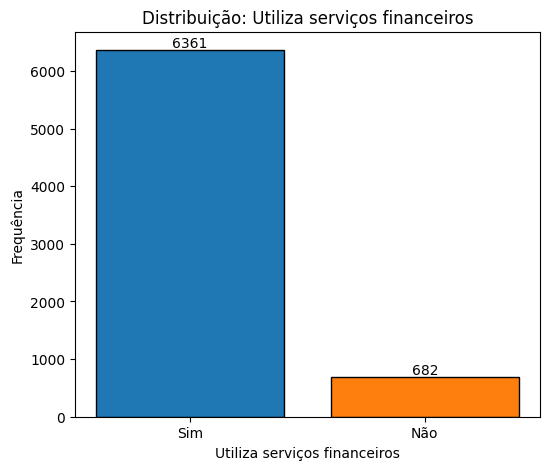

-->Tipo de dados:
str

-->Valores únicos:
2 valores distintos
<StringArray>
['Não', 'Sim']
Length: 2, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Utiliza serviços financeiros
Sim    6361
Não     682
Name: count, dtype: int64

-->Frequência relativa(%):
Utiliza serviços financeiros
Sim    90.316626
Não     9.683374
Name: proportion, dtype: float64


In [56]:
#Análiseda coluna "Utiliza serviços financeiros"

col = "Utiliza serviços financeiros"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Utiliza serviços financeiros" indica se a empresa utiliza serviços financeiros (Sim/Não). Ela é categórica booleana, formatada como texto.

Existem 2 categorias distintas: 'Sim' e 'Não'. Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias está desbalanceada, 90,31% das empresas utilizam serviços financeiros e 9,68% não.

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, pois empresas que utilizam serviço financeiro podem ter menor taxa de churn devido a uma dependência maior do nosso serviço, devido a um maior nível de utilização do sistema.

### 1.8 PossuiContador

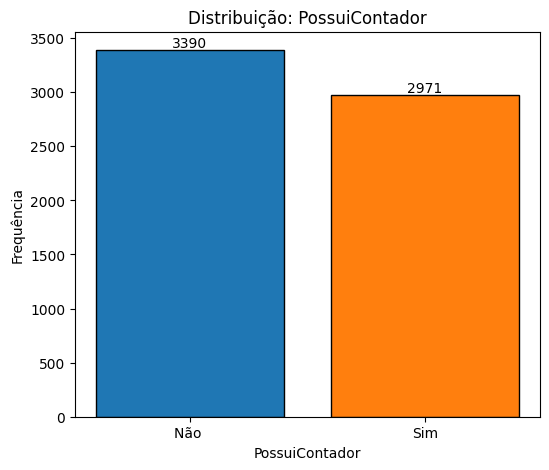

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
[nan, 'Não ', 'Sim']
Length: 3, dtype: str

-->Valores nulos:
682
9.683373562402386% do total

-->Frequência absoluta:
PossuiContador
Não     3390
Sim     2971
Name: count, dtype: int64

-->Frequência relativa(%):
PossuiContador
Não     53.293507
Sim     46.706493
Name: proportion, dtype: float64


In [57]:
#Análise da coluna "PossuiContador"

col = "PossuiContador"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "PossuiContador" representa se a empresa tem um contador. Ela é categórica booleana, formatada como texto.

Existem 2 categorias distintas: "Sim" e "Não". Existem valores ausentes nessa variável, são 682 valores (9,68%) possivelmente valores ausentes ao acaso. Não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é bem equilibrada, sendo 51,69% dos registros "Sim" e 48,30% "Não".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas com contador podem apresentar menor churn, pois a sua presença aumenta a dependência do sistema, visto que ele o utiliza nas suas atividades do dia a dia, como controle financeiro e relatórios.

### 1.9 Faz conciliação bancária

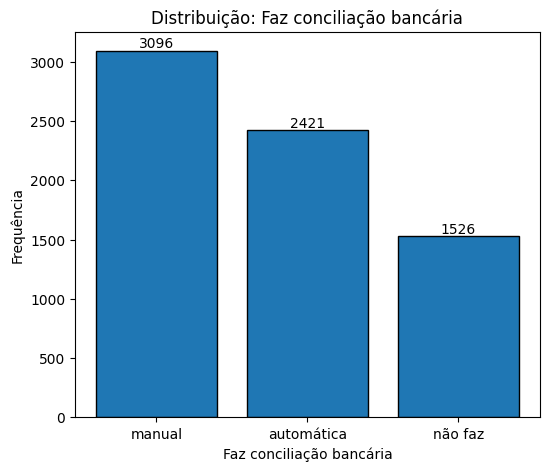

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
['automática', 'manual', 'não faz']
Length: 3, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Faz conciliação bancária
manual        3096
automática    2421
não faz       1526
Name: count, dtype: int64

-->Frequência relativa(%):
Faz conciliação bancária
manual        43.958540
automática    34.374556
não faz       21.666903
Name: proportion, dtype: float64


In [58]:
#Análise da coluna "Faz conciliação bancária"

col = "Faz conciliação bancária"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Faz conciliação bancária" representa se a empresa realiza conciliação bancária (manual ou automática). Ela é categórica nominal, formatada como texto.

Existem 3 categorias distintas: "automática", "manual" e "não faz". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 43,95% "manual", 34,37% "automática" e 21,66% "não faz".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas que fazem a conciliação bancária manual podem apresentar maior churn, o que pode estar associado a um menor engajamento com o sistema, visto que a escolha por esse modo é opcional.

### 1.10 Frequência de utilização de feature do sistema: Módulo financeiro

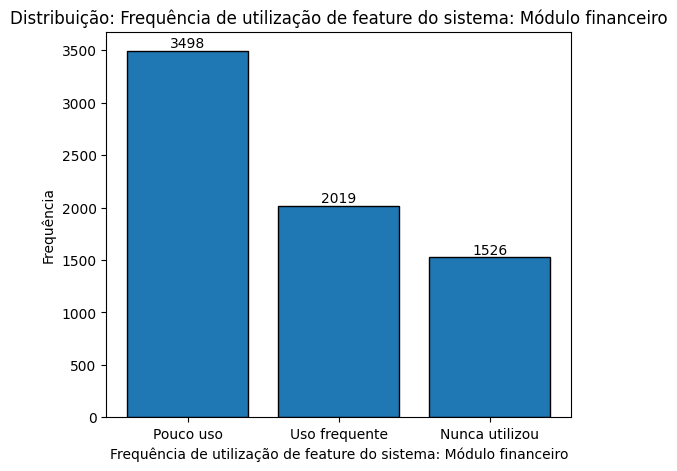

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
['Pouco uso', 'Uso frequente', 'Nunca utilizou']
Length: 3, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Frequência de utilização de feature do sistema: Módulo financeiro
Pouco uso         3498
Uso frequente     2019
Nunca utilizou    1526
Name: count, dtype: int64

-->Frequência relativa(%):
Frequência de utilização de feature do sistema: Módulo financeiro
Pouco uso         49.666335
Uso frequente     28.666761
Nunca utilizou    21.666903
Name: proportion, dtype: float64


In [59]:
#Análise da coluna "Frequência de utilização de feature do sistema: Módulo financeiro"

col = "Frequência de utilização de feature do sistema: Módulo financeiro"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Frequência de utilização de feature do sistema: Módulo financeiro" representa frequência de utilização do módulo financeiro do sistema (ex: Pouco uso, Uso frequente). Ela é categórica nominal, formatada como texto.

Existem 3 categorias distintas: "Pouco uso", "Uso frequente" e "Nunca utilizou". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 49,66% "Pouco uso", 38,66% "Uso frequente" e 21,66% "Nunca utilizou".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas que utilizam mais essa feature podem apresentar menor churn, pois indica um engajamento maior com o sistema.

### 1.11 Frequência de utilização de feature do sistema: Emissão de nota fiscal

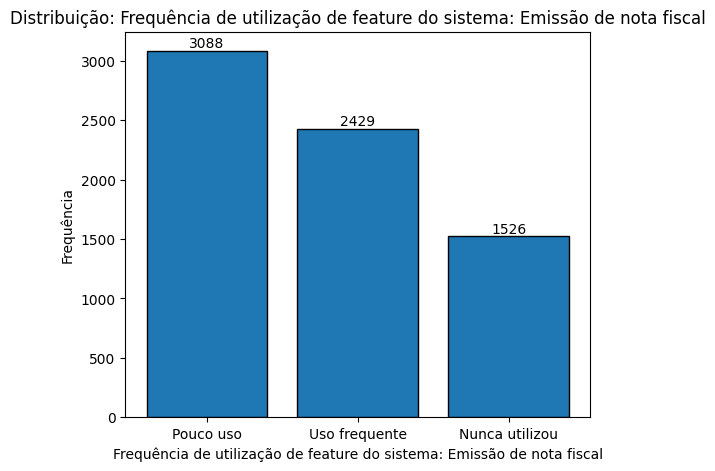

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
['Uso frequente', 'Pouco uso', 'Nunca utilizou']
Length: 3, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Frequência de utilização de feature do sistema: Emissão de nota fiscal
Pouco uso         3088
Uso frequente     2429
Nunca utilizou    1526
Name: count, dtype: int64

-->Frequência relativa(%):
Frequência de utilização de feature do sistema: Emissão de nota fiscal
Pouco uso         43.844952
Uso frequente     34.488144
Nunca utilizou    21.666903
Name: proportion, dtype: float64


In [60]:
#Análise da coluna "Frequência de utilização de feature do sistema: Emissão de nota fiscal"

col = "Frequência de utilização de feature do sistema: Emissão de nota fiscal"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Frequência de utilização de feature do sistema: Emissão de nota fiscal" representa frequência de utilização do módulo de emissão de nota fiscal. Ela é categórica nominal, formatada como texto.

Existem 3 categorias distintas: "Pouco uso", "Uso frequente" e "Nunca utilizou". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 43,86% "Pouco uso", 34,48% "Uso frequente" e 21,66% "Nunca utilizou".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas que utilizam mais essa feature podem apresentar menor churn, pois indica um engajamento maior com o sistema.

### 1.12 Frequência de utilização de feature do sistema: Integração bancária

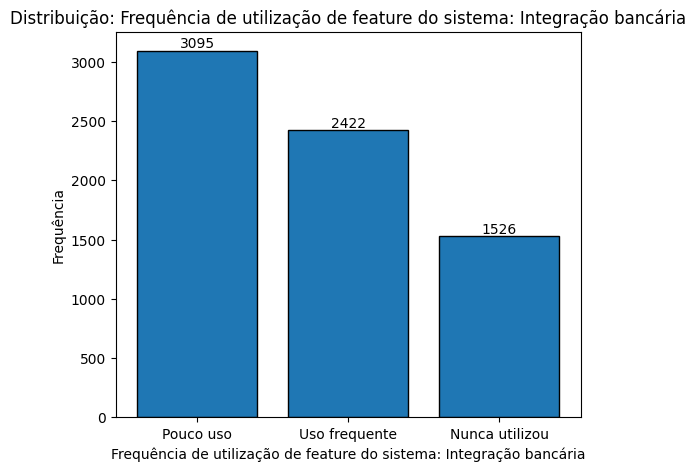

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
['Pouco uso', 'Uso frequente', 'Nunca utilizou']
Length: 3, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Frequência de utilização de feature do sistema: Integração bancária
Pouco uso         3095
Uso frequente     2422
Nunca utilizou    1526
Name: count, dtype: int64

-->Frequência relativa(%):
Frequência de utilização de feature do sistema: Integração bancária
Pouco uso         43.944342
Uso frequente     34.388755
Nunca utilizou    21.666903
Name: proportion, dtype: float64


In [61]:
#Análise da coluna "Frequência de utilização de feature do sistema: Integração bancária"

col = "Frequência de utilização de feature do sistema: Integração bancária"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Frequência de utilização de feature do sistema: Integração bancária" representa frequência de utilização do módulo de Integração bancária. Ela é categórica nominal, formatada como texto.

Existem 3 categorias distintas: "Pouco uso", "Uso frequente" e "Nunca utilizou". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 43,94% "Pouco uso", 34,38% "Uso frequente" e 21,66% "Nunca utilizou".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas que utilizam mais essa feature podem apresentar menor churn, pois indica um engajamento maior com o sistema.

### 1.13 Frequência de utilização de feature do sistema: Módulo de vendas

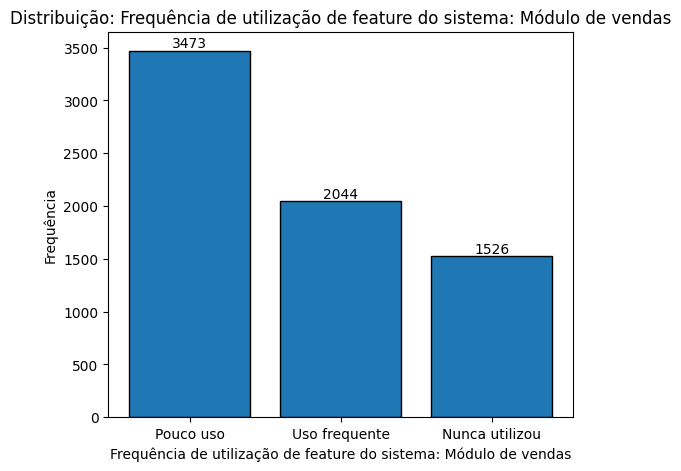

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
['Pouco uso', 'Uso frequente', 'Nunca utilizou']
Length: 3, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Frequência de utilização de feature do sistema: Módulo de vendas
Pouco uso         3473
Uso frequente     2044
Nunca utilizou    1526
Name: count, dtype: int64

-->Frequência relativa(%):
Frequência de utilização de feature do sistema: Módulo de vendas
Pouco uso         49.311373
Uso frequente     29.021724
Nunca utilizou    21.666903
Name: proportion, dtype: float64


In [62]:
#Análise da coluna "Frequência de utilização de feature do sistema: Módulo de vendas"

col = "Frequência de utilização de feature do sistema: Módulo de vendas"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Frequência de utilização de feature do sistema: Módulo de vendas" representa frequência de utilização do módulo de vendas. Ela é categórica nominal, formatada como texto.

Existem 3 categorias distintas: "Pouco uso", "Uso frequente" e "Nunca utilizou". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 49,31% "Pouco uso", 29,02% "Uso frequente" e 21,66% "Nunca utilizou".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas que utilizam mais essa feature podem apresentar menor churn, pois indica um engajamento maior com o sistema.

### 1.14 Frequência de utilização de feature do sistema: Relatórios

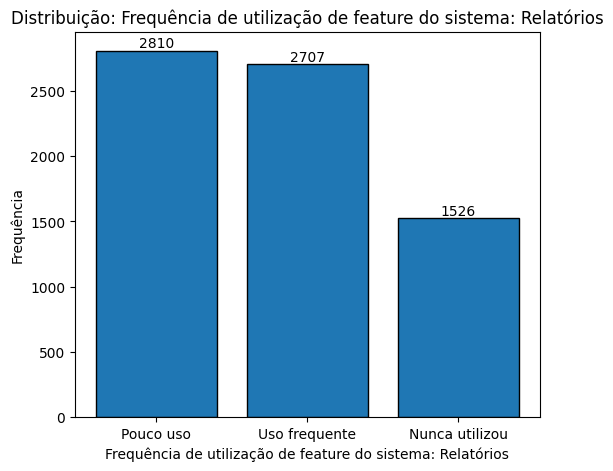

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
['Pouco uso', 'Uso frequente', 'Nunca utilizou']
Length: 3, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Frequência de utilização de feature do sistema: Relatórios
Pouco uso         2810
Uso frequente     2707
Nunca utilizou    1526
Name: count, dtype: int64

-->Frequência relativa(%):
Frequência de utilização de feature do sistema: Relatórios
Pouco uso         39.897771
Uso frequente     38.435326
Nunca utilizou    21.666903
Name: proportion, dtype: float64


In [63]:
#Análise da coluna "Frequência de utilização de feature do sistema: Relatórios"

col = "Frequência de utilização de feature do sistema: Relatórios"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Frequência de utilização de feature do sistema: Relatórios" representa frequência de utilização do módulo de relatórios. Ela é categórica nominal, formatada como texto.

Existem 3 categorias distintas: "Pouco uso", "Uso frequente" e "Nunca utilizou". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 39,89% "Pouco uso", 38,43% "Uso frequente" e 21,66% "Nunca utilizou".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas que utilizam mais essa feature podem apresentar menor churn, pois indica um engajamento maior com o sistema.

### 1.15 Frequência de utilização de feature do sistema: Utilização de APIs de integração

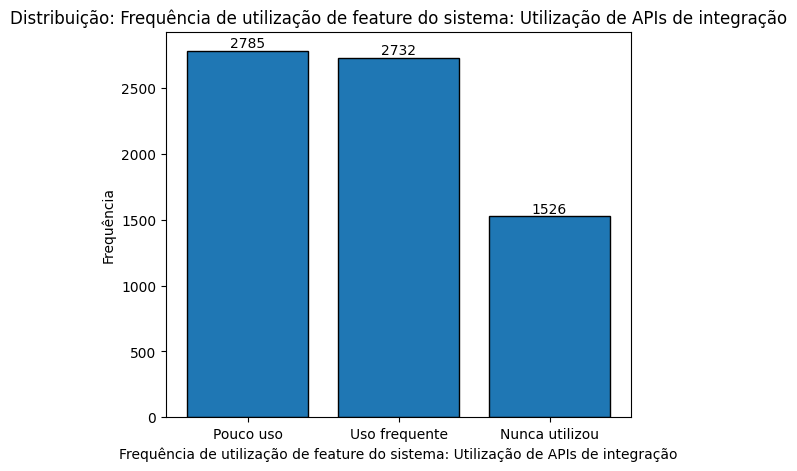

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
['Pouco uso', 'Nunca utilizou', 'Uso frequente']
Length: 3, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Frequência de utilização de feature do sistema: Utilização de APIs de integração
Pouco uso         2785
Uso frequente     2732
Nunca utilizou    1526
Name: count, dtype: int64

-->Frequência relativa(%):
Frequência de utilização de feature do sistema: Utilização de APIs de integração
Pouco uso         39.542808
Uso frequente     38.790288
Nunca utilizou    21.666903
Name: proportion, dtype: float64


In [64]:
#Análise da coluna "Frequência de utilização de feature do sistema: Utilização de APIs de integração"

col = "Frequência de utilização de feature do sistema: Utilização de APIs de integração"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Frequência de utilização de feature do sistema: Utilização de APIs de integração" representa frequência de utilização do módulo utilização de APIs de integração. Ela é categórica nominal, formatada como texto.

Existem 3 categorias distintas: "Pouco uso", "Uso frequente" e "Nunca utilizou". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 39,54% "Pouco uso", 38,79% "Uso frequente" e 21,66% "Nunca utilizou".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas que utilizam mais essa feature podem apresentar menor churn, pois indica um engajamento maior com o sistema.

### 1.16 Contrato

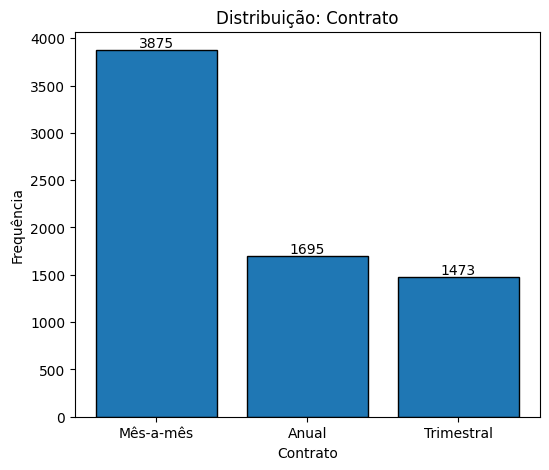

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
['Mês-a-mês', 'Trimestral', 'Anual']
Length: 3, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Contrato
Mês-a-mês     3875
Anual         1695
Trimestral    1473
Name: count, dtype: int64

-->Frequência relativa(%):
Contrato
Mês-a-mês     55.019168
Anual         24.066449
Trimestral    20.914383
Name: proportion, dtype: float64


In [65]:
#Análise da coluna "Contrato"

col = "Contrato"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Contrato" representa o tipo de contrato com o cliente (ex: Mês-a-mês, Trimestral, Anual). Ela é categórica nominal, formatada como texto.

Existem 3 categorias distintas: "Mês-a-mês", "Trimestral" e "Anual". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 55% "Mês-a-mês", 24% "Anual" e 20,9% "Trimestral".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, empresas com contratos mais curtos tendem a apresentar maior taxa de churn, devido à maior flexibilidade de saída.

### 1.17 Emite boletos

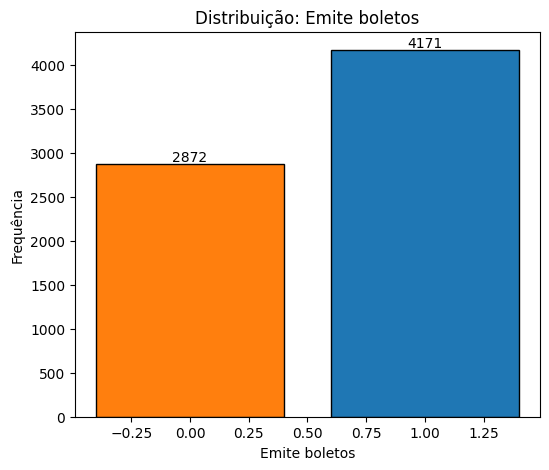

-->Tipo de dados:
int64

-->Valores únicos:
2 valores distintos
[1 0]

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Emite boletos
1    4171
0    2872
Name: count, dtype: int64

-->Frequência relativa(%):
Emite boletos
1    59.221922
0    40.778078
Name: proportion, dtype: float64


In [66]:
#Análise da coluna "Emite boletos"

col = "Emite boletos"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

Essa coluna é igual à coluna "Emite boletos. 1", onde a única diferença é que na outra os dados já estão melhores formatados para a análise, por isso decidi analisá-la.

### 1.18 Emite boletos.1

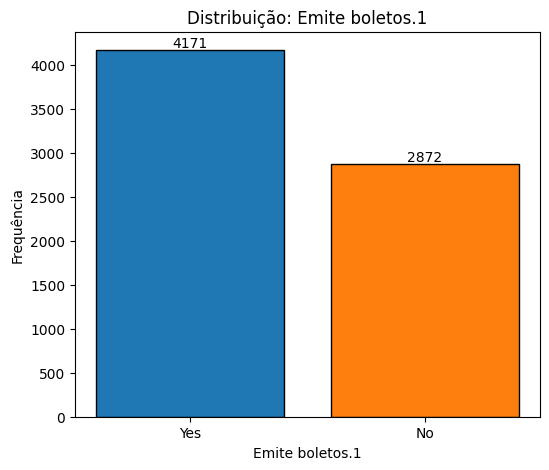

-->Tipo de dados:
str

-->Valores únicos:
2 valores distintos
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Emite boletos.1
Yes    4171
No     2872
Name: count, dtype: int64

-->Frequência relativa(%):
Emite boletos.1
Yes    59.221922
No     40.778078
Name: proportion, dtype: float64


In [67]:
#Análise da coluna "Emite boletos.1"

col = "Emite boletos.1"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Emite boletos.1" representa se a empresa emite boletos. Ela é categórica booleana, formatada como texto.

Existem 2 categorias distintas: "Yes" e "No". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é bem equilibrada, sendo 59,22% dos registros "Yes" e 40,77% "No".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn, pois as empresas que emitem boletos podem ter menor churn, devido a esta ser uma função fundamental, aumentando a dependência do cliente à plataforma.

### 1.19 Tipo Pagamento

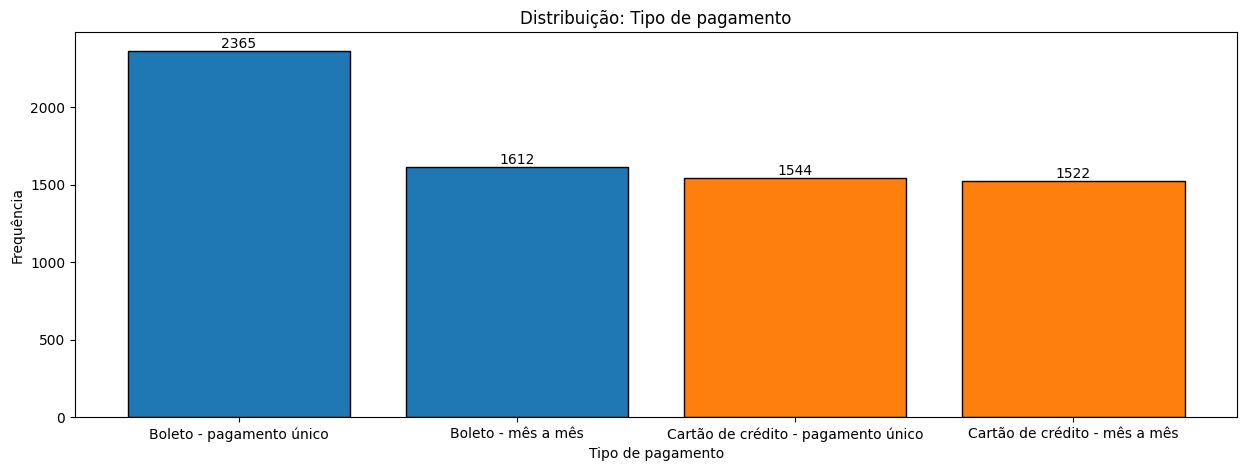

-->Tipo de dados:
str

-->Valores únicos:
4 valores distintos
<StringArray>
[           'Boleto - pagamento único',                  'Boleto - mês a mês',
 'Cartão de crédito - pagamento único',       'Cartão de crédito - mês a mês']
Length: 4, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Tipo de pagamento
Boleto - pagamento único               2365
Boleto - mês a mês                     1612
Cartão de crédito - pagamento único    1544
Cartão de crédito - mês a mês          1522
Name: count, dtype: int64

-->Frequência relativa(%):
Tipo de pagamento
Boleto - pagamento único               33.579441
Boleto - mês a mês                     22.887974
Cartão de crédito - pagamento único    21.922476
Cartão de crédito - mês a mês          21.610109
Name: proportion, dtype: float64


In [68]:
#Análise da coluna "Tipo de pagamento"

col = "Tipo de pagamento"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(15,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:blue', 'tab:orange', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Tipo de pagamento" representa método de pagamento utilizado pelo cliente.. Ela é categórica nominal, formatada como texto.

Existem 4 categorias distintas: "Boleto - pagamento único", "Boleto - mês a mês", "Cartão de crédito - pagamento único" e "Cartão de crédito - mês a mês". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é levemente equilibrada, sendo 33,57% "Boleto - pagamento único", 22,88% "Boleto - mês a mês", 21,92% "Cartão de crédito - pagamento único" e 21,61% "Cartão de crédito - mês a mês".

Essa variável é útil e possui potencial de segmentação. Também faz sentido cruzá-la com churn tanto individualmente quanto agrupadas, empresas que utilizam diferentes pagamentos podem ter chance de churn maior, devido a facilidade de cancelamento para quem paga mês a mês .

### 1.20 Receita mensal

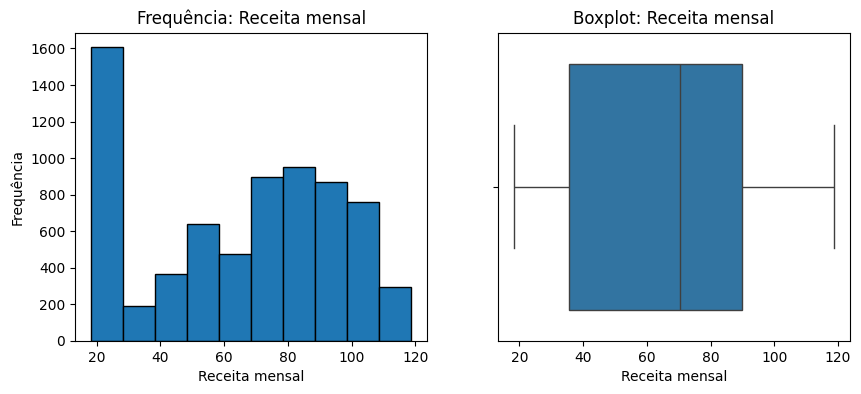

-->Tipo de dados:
float64

-->Valores únicos:
1585 valores distintos
[29.85 56.95 42.3  ... 77.   30.9  28.6 ]

-->Valores nulos:
0
0.0% do total

-->Estatisticas descritivas:
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Receita mensal, dtype: float64




In [69]:
#Análise da coluna "Receita mensal" 

col = "Receita mensal"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Estatisticas descritivas
estatisticas_descritivas = df[col].describe()

#Gráficos
plt.figure(figsize=(10,4))

#Histograma
plt.subplot(1,2,1)
grafico_hist = plt.hist(df[col], ec='k')
plt.title(f'Frequência: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")

#Boxplot
plt.subplot(1,2,2)
grafico_box = sns.boxplot(x=col, data=df)
plt.title(f'Boxplot: {col}')
plt.xlabel(col)
plt.show()

print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Estatisticas descritivas:\n{estatisticas_descritivas}\n\n")

A variável "Receita mensal" representa a receita mensal gerada pelo cliente. Trata-se de uma variável numérica discreta, registrada como int, sem nenhum valores ausentes.

Estatísticas descritivas:

- Média: 64,76
- Mediana: 70,35
- Desvio Padrão: 30,09
- Valor Mínimo: 18,25
- Valor Máximo: 118,75

A distribuição é assimetrica negativa, observada por meio dos gráficos, sem outliers.

Em termos de qualidade, não encontrei nenhum problema. 

Possível agrupamento identificado, visto que as receitas podem ser agrupadas em faixas.

Essa variável pode ser usada em cruzamentos com o Churn, visto que empresas com menor receita podem ter maior churn, o que pode estar associado a uma maior sensibilidade ao preço.

### 1.21 Receita total

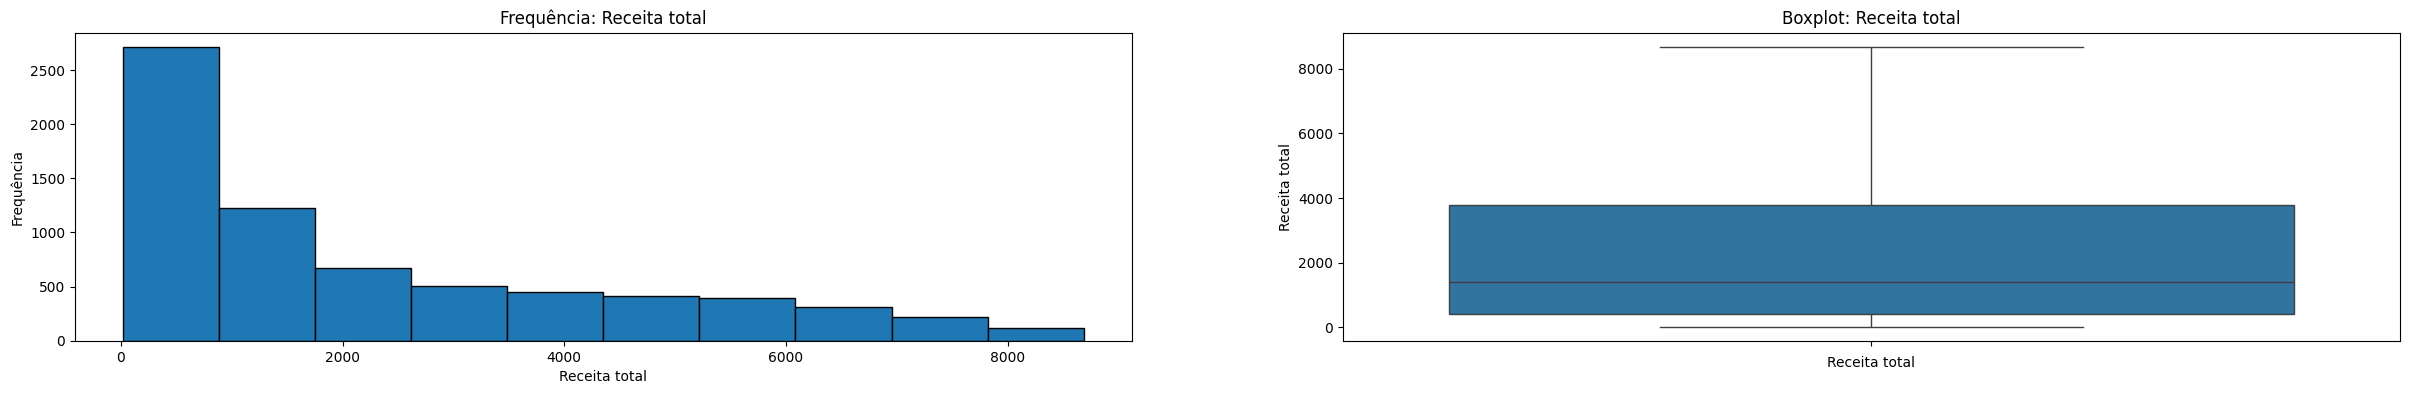

-->Tipo de dados:
float64

-->Valores únicos:
6531 valores distintos
[  29.85 1889.5  1840.75 ... 3066.45  240.45   40.1 ]

-->Valores nulos:
11
0.1561834445548772% do total

-->Estatisticas descritivas:
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: Receita total, dtype: float64




In [70]:
#Análise da coluna "Receita total" 

col = "Receita total"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100



#Estatisticas descritivas
estatisticas_descritivas = df[col].describe()

#Gráficos
plt.figure(figsize=(30,4))

#Histograma
plt.subplot(1,2,1)
grafico_hist = plt.hist(df[col], ec='k')
plt.title(f'Frequência: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")

#Boxplot
#Tirando valores nulos para plotar boxplot
sem_nulos= df[col].dropna()

plt.subplot(1,2,2)
grafico_box = sns.boxplot(data=sem_nulos)
plt.title(f'Boxplot: {col}')
plt.xlabel(col)
plt.show()

print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Estatisticas descritivas:\n{estatisticas_descritivas}\n\n")

A variável "Receita total" representa a receita total gerada pelo cliente. Trata-se de uma variável numérica discreta, registrada como int, 11 valores nulos (0.15%), possivelmente valores ausentes ao acaso.

Estatísticas descritivas:

- Média: 2283,3
- Mediana: 1397,47
- Desvio Padrão: 2266,77
- Valor Mínimo: 18,8
- Valor Máximo: 8684,8

A distribuição é assimetrica positiva, observada por meio dos gráficos, sem outliers.

Em termos de qualidade, não encontrei nenhum problema. 

Possível agrupamento identificado, visto que as receitas podem ser agrupadas em faixas.

Essa variável pode ser usada em cruzamentos com o Churn, visto que empresas com menor receita podem ter maior churn, pois elas tendem a ser mais sensíveis ao preço.

### 1.22 Churn

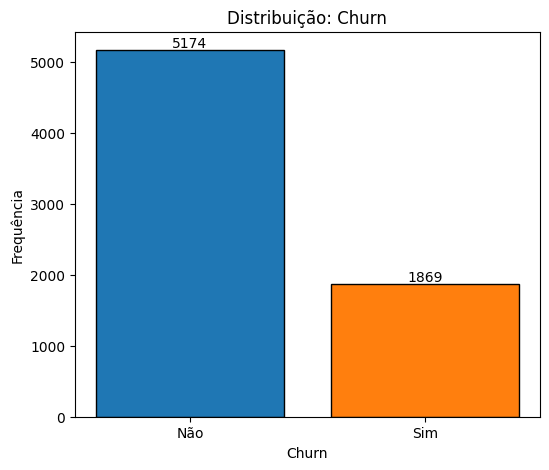

-->Tipo de dados:
str

-->Valores únicos:
2 valores distintos
<StringArray>
['Não', 'Sim']
Length: 2, dtype: str

-->Valores nulos:
0
0.0% do total

-->Frequência absoluta:
Churn
Não    5174
Sim    1869
Name: count, dtype: int64

-->Frequência relativa(%):
Churn
Não    73.463013
Sim    26.536987
Name: proportion, dtype: float64


In [71]:
#Análise da coluna "Churn"

col = "Churn"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "Churn" representa se houve Churn. Ela é categórica booleana, formatada como texto.

Existem 2 categorias distintas: "Sim" e "Não". Não há valores ausentes nessa variável e não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 73,46% dos registros "Não" e 26,53% "Sim".

Essa é a variável alvo.

### 1.23mes_churn

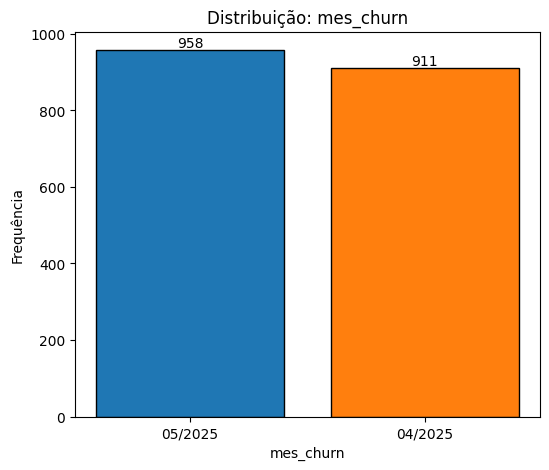

-->Tipo de dados:
str

-->Valores únicos:
3 valores distintos
<StringArray>
[nan, '04/2025', '05/2025']
Length: 3, dtype: str

-->Valores nulos:
5174
73.4630129206304% do total

-->Frequência absoluta:
mes_churn
05/2025    958
04/2025    911
Name: count, dtype: int64

-->Frequência relativa(%):
mes_churn
05/2025    51.257357
04/2025    48.742643
Name: proportion, dtype: float64


In [72]:
#Análise da coluna "mes_churn"

col = "mes_churn"

#Tipo da variável
tipo_variavel = df[col].dtype

#Valores únicos
valores_dist = df[col].unique()
#Quantidade Valores únicos
qtd_valores_dist = valores_dist.size

#Valores Nulos
valores_nulos = df[col].isnull().sum()
# % de nulos
total_valores = df[col].count() + valores_nulos
pct_nulos = (valores_nulos / total_valores) * 100

#Frequência absoluta
freq_ab = df[col].value_counts()
#Frequência relativa
freq_rel = df[col].value_counts(normalize=True)*100


#Gráfico
plt.figure(figsize=(6,5))
grafico = plt.bar(freq_ab.index, freq_ab, color = ['tab:blue', 'tab:orange'], ec='k' )
plt.title(f'Distribuição: {col}')
plt.xlabel(col)
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.bar_label(grafico, label_type='edge')
plt.show()


print(f"-->Tipo de dados:\n{tipo_variavel}\n\n-->Valores únicos:\n{qtd_valores_dist} valores distintos\n{valores_dist}\n\n-->Valores nulos:\n{valores_nulos}\n{pct_nulos}% do total\n\n-->Frequência absoluta:\n{freq_ab}\n\n-->Frequência relativa(%):\n{freq_rel}")

A variável "mes_churn" representa em que mes que houve o churn. Ela é categórica nominal, formatada como texto.

Existem 2 categorias distintas: "04/2025" e "05/2025". Existem 5174 valores nulos (73,46%), valor não ausente ao acaso, os valores nulos indicam que a empresa não teve churn. Não há inconsistências como variação de escrita, capitalização ou categorias fora do padrão.

A distribuição entre as categorias é desequilibrada, sendo 51,25% dos registros "05/2025" e 48,74% "04/2025".


# 2. Tratamento

## Problemas identificados no EDA e decisões tomadas

-  Colunas duplicadas: Emite boletos e Emite boletos.1

    - Emite boletos: 0 e 1  
    - Emite boletos.1: Yes e No  

    Decisão: manter apenas Emite boletos, padronizando para Sim e Não.

- Valores nulos

    | Coluna | % nulos | Decisão |
    |--------|--------|----------|
    | possui_contador | 9,68% | Ausente ao acaso |
    | receita_total | 0,15% | Ausente ao acaso |
    | mes_churn | 73,46% | **Ausente não ao acaso** |

    Decisão: manter valores nulos, pois não afetarão as análises.

- Formatação

    - O nome da coluna meses_permanencia tem um espaço ao final do nome  



### Colunas duplicadas: Emite boletos e Emite boletos.1

In [73]:
# excluir coluna 'Emite boletos.1'
df = df.drop('Emite boletos.1', axis=1)

# trocando valores 'Yes' e 'No' por 'Sim' e 'Não'
df['Emite boletos'] = df['Emite boletos'].replace({'Yes': 'Sim', 'No': 'Não'})

### Formatando nome da coluna meses_permanencia

In [74]:
# formatando nome da coluna
df = df.rename(columns={"Meses de permanência ": "Meses de permanência"})

# 3. Análise Bivariada

- Agora vamos, cruzar a variável churn com outras para identificar padrões e possíveis fatores associados à evasão de clientes.

## 3.1 Análise Temporal

### A taxa de churn realmente aumentou? Há tendência de crescimento?

### Churn ao longo dos meses

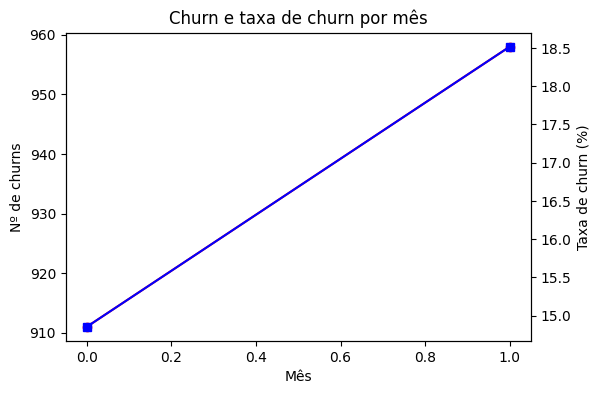

,mes,churns,ativos_inicio_mes,taxa_churn
0,04/2025,911,6132,14.856491
1,05/2025,958,5174,18.515655


In [75]:
#Filtrando a tabela para empresas que fizeram churn
churns = df[df['mes_churn'].notnull()]

#Calculando Numero de churns por mes
churns_mes = churns["mes_churn"].value_counts().sort_index()

#Total de clientes iniciais
total_clientes = df.shape[0]
#Numero de churns em abril
churns_abril = churns[churns['mes_churn']=='04/2025'].shape[0]
#Numero de churns em maio
churns_maio = churns[churns['mes_churn']=='05/2025'].shape[0]
#Calculo de clientes ativos em cada mes
ativos_abril = total_clientes - churns_abril
ativos_maio = ativos_abril - churns_maio


#DataFrame para analise
analise_temporal = pd.DataFrame({
    "mes": ["04/2025", "05/2025"],
    "churns": churns_mes.values,
    "ativos_inicio_mes": [ativos_abril, ativos_maio]
})

#Calculo da taxa de churn em cada mês em %
analise_temporal["taxa_churn"] = (analise_temporal["churns"] / analise_temporal["ativos_inicio_mes"]) * 100

#Grafico
fig, ax1 = plt.subplots(figsize=(6,4))
ax2 = ax1.twinx()
analise_temporal["churns"].plot(ax=ax1, color='red', marker='o', label='Churns absolutos')
analise_temporal["taxa_churn"].plot(ax=ax2, color='blue', marker='s', label='Taxa de churn (%)')
ax1.set_ylabel("Nº de churns")
ax2.set_ylabel("Taxa de churn (%)")
ax1.set_xlabel("Mês")
ax1.set_title("Churn e taxa de churn por mês")
plt.show()

analise_temporal

- Mês de Abril teve 911 churns, com uma taxa de 14,85%.
- Mês de Maio teve 958 churns, com uma taxa de 18,51%.
- Aumento de 3,66 pontos percentuais na taxa de churn de Abril para Maio, confirmando assim a hipótese sobre o aumento de churn.
- Apesar do aumento, não se pode confirmar tendência de crescimento no número de churns, pois temos dados de apenas dois meses.
- Alguma mudança no serviço pode ter influenciado o aumento, por isso recomendo análise mais profunda para descobrir.

## 3.2 Agrupamentos

### Características da empresa, como tipo, ano de fundação, possui mais de um sócio e número de funcionários, estão associadas ao churn?

### 3.2.1 Churn x Tipo de empresa

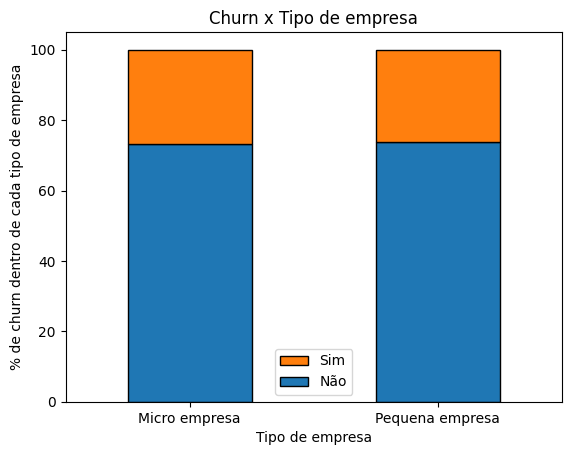

Churn,Não,Sim
Tipo de empresa,,
Micro empresa,73.079128,26.920872
Pequena empresa,73.839662,26.160338


In [76]:
#Criando a tabela Crosstab
crosstab = pd.crosstab(df["Tipo de empresa"], df["Churn"], normalize="index") *100


#Gráfico
grafico = crosstab.plot(kind="bar", stacked=True, ec='k')
plt.title("Churn x Tipo de empresa")
plt.xlabel("Tipo de empresa")
plt.ylabel("% de churn dentro de cada tipo de empresa")
plt.xticks(rotation=0)


#Mudando ordem da legenda
handles, labels = plt.gca().get_legend_handles_labels()

#Especificando a ordem
order = [1, 0]

#Refazendo a legenda com a nova ordem
plt.legend([handles[i] for i in order], [labels[i] for i in order])

plt.show()

crosstab



- Entre as micro empresas 26,92% apresentaram churn.
- Entre as pequenas empresas, a taxa foi de 26,26%.
- A distribuição de churn entre os dois tipos é bastante equilibrada, com leve predominância nas pequenas empresas.
- Esse equilibrio não demonstra que o porte da empresa tenha influência no churn.

### 3.2.2 Churn x Ano Fundação

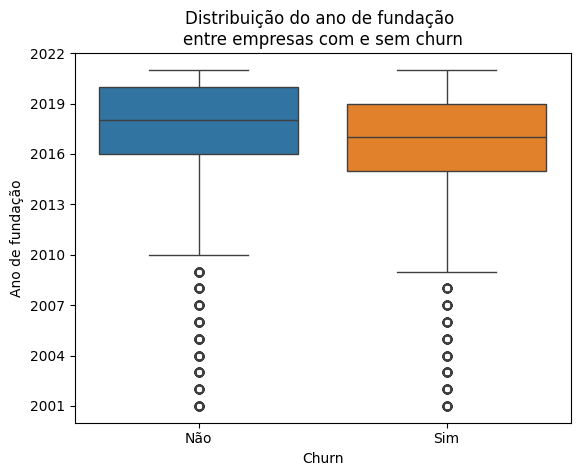

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Não,5174.0,2017.127174,4.156245,2001.0,2016.0,2018.0,2020.0,2021.0
Sim,1869.0,2015.654896,5.452167,2001.0,2015.0,2017.0,2019.0,2021.0


In [77]:

import matplotlib.ticker as ticker

#Gráfico
sns.boxplot(x='Churn', y= 'Fundação da empresa',hue='Churn', data=df)
plt.title("Distribuição do ano de fundação \nentre empresas com e sem churn")
plt.xlabel("Churn")
plt.ylabel("Ano de fundação")

# Forçar eixo y com valores inteiros
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.show()

#Estatísticas
dados_agrupados = df.groupby("Churn")["Fundação da empresa"].describe()
dados_agrupados

- Empresas que churnaram foram fundadas tem ano de fundação médio de 2015.6
- Empresas que não churnaram tem média 2017
- Essa diferença de ~1,5 anos sugere que o ano de fundação isolado não é um fator para de influência para o churn

### 3.2.3 Churn x Possui mais de um sócio

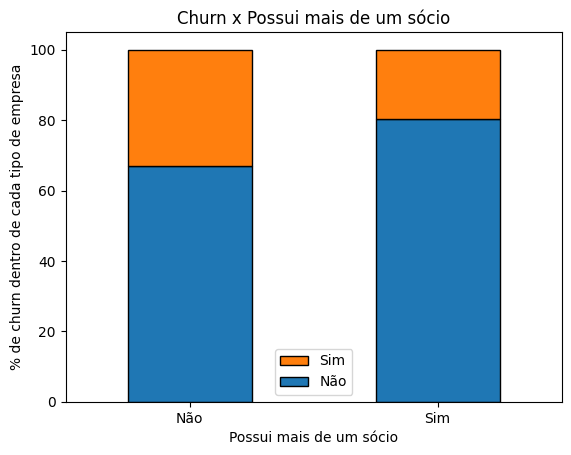

Churn,Não,Sim
Possui mais de um sócio,,
Não,67.042021,32.957979
Sim,80.335097,19.664903


In [78]:
#Criando a tabela Crosstab
crosstab = pd.crosstab(df["Possui mais de um sócio"], df["Churn"], normalize="index") *100


#Gráfico
grafico = crosstab.plot(kind="bar", stacked=True, ec='k')
plt.title("Churn x Possui mais de um sócio")
plt.xlabel("Possui mais de um sócio")
plt.ylabel("% de churn dentro de cada tipo de empresa")
plt.xticks(rotation=0)


#Mudando ordem da legenda
handles, labels = plt.gca().get_legend_handles_labels()

#Especificando a ordem
order = [1, 0]

#Refazendo a legenda com a nova ordem
plt.legend([handles[i] for i in order], [labels[i] for i in order])

plt.show()

crosstab

- Entre empresas com apenas um sócio, 32,96% apresentaram churn.

- Entre empresas com mais de um sócio, a taxa foi de 19,66%.

- Há uma diferença relevante entre os grupos, com maior churn nas empresas com um único sócio.

- Os dados sugere que a quantidade de sócios pode influenciar no churn.

### 3.2.4 Churn x Funcionarios

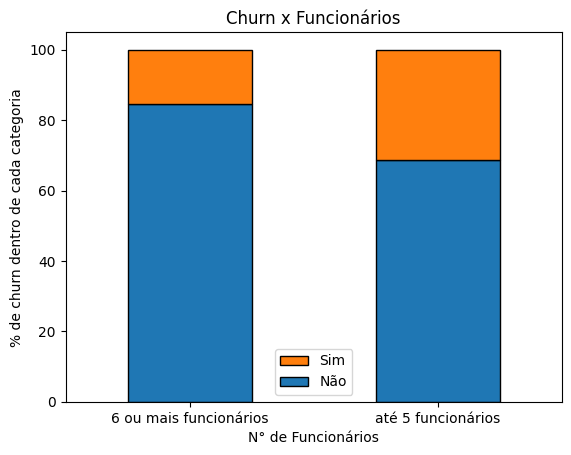

Churn,Não,Sim
Funcionários,,
6 ou mais funcionários,84.549763,15.450237
até 5 funcionários,68.720860,31.279140


In [79]:
#Crosstab
crosstab = pd.crosstab(df["Funcionários"], df["Churn"], normalize="index") *100


#Gráfico
grafico = crosstab.plot(kind="bar", stacked=True, ec='k')
plt.title("Churn x Funcionários")
plt.xlabel("N° de Funcionários")
plt.ylabel("% de churn dentro de cada categoria")
plt.xticks(rotation=0)

#Mudando ordem da legenday
handles, labels = plt.gca().get_legend_handles_labels()

#Especificando a ordem
order = [1, 0]

#Refazendo a legenda com a nova ordem
plt.legend([handles[i] for i in order], [labels[i] for i in order])

plt.show()

crosstab


- Entre as empresas que possuem até 5 funcionários, 31,27% tiveram churn.
- Entre as empresas com 6 ou mais funcionários, 15,45% tiveram churn.
- Pode-se observar que as empresas que possuem até 5 funcionários, tem significativamente maior percentual e churn.
- Os dados sugerem que a estrutura das empresas seja um fator de influência no churn.

### O uso de funcionalidades do sistema está relacionado ao churn?

### 3.2.5 Churn x Frequência de utilizacão de recursos do sistema

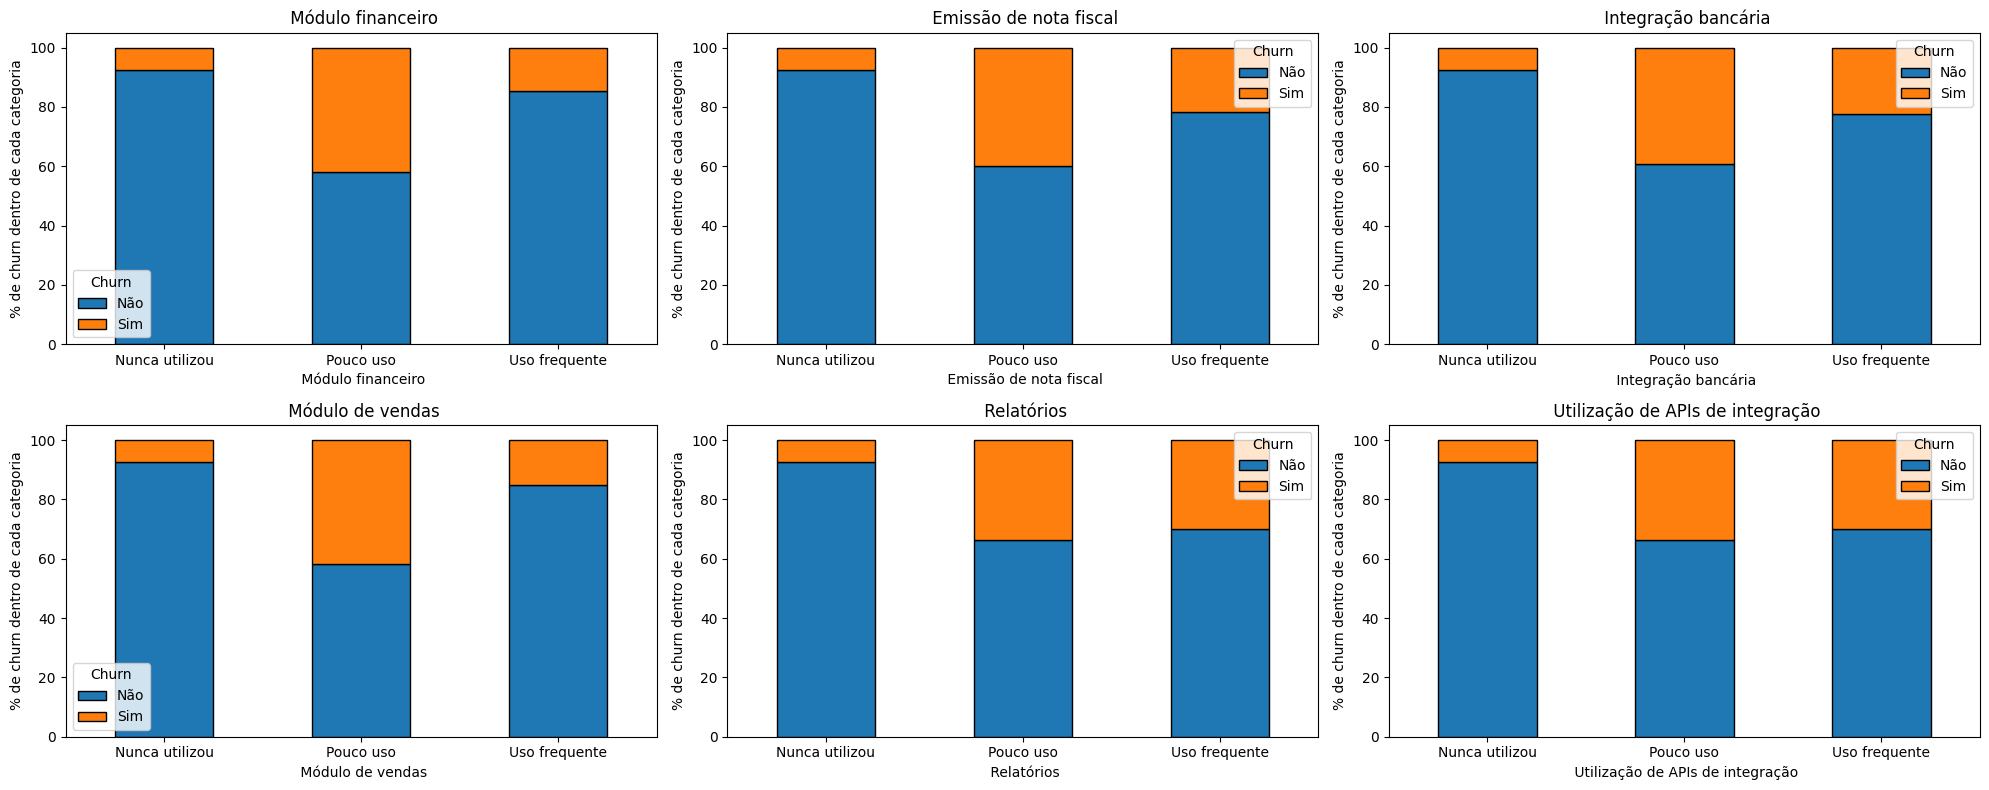


==== Frequência de utilização de feature do sistema: Módulo financeiro ====



Churn,Não,Sim
Frequência de utilização de feature do sistema: Módulo financeiro,,
Nunca utilizou,92.595020,7.404980
Pouco uso,58.233276,41.766724
Uso frequente,85.388806,14.611194



==== Frequência de utilização de feature do sistema: Emissão de nota fiscal ====



Churn,Não,Sim
Frequência de utilização de feature do sistema: Emissão de nota fiscal,,
Nunca utilizou,92.595020,7.404980
Pouco uso,60.071244,39.928756
Uso frequente,78.468506,21.531494



==== Frequência de utilização de feature do sistema: Integração bancária ====



...

Churn,Não,Sim
Frequência de utilização de feature do sistema: Módulo de vendas,,
Nunca utilizou,92.595020,7.404980
Pouco uso,58.364526,41.635474
Uso frequente,84.833659,15.166341



==== Frequência de utilização de feature do sistema: Relatórios ====



Churn,Não,Sim
Frequência de utilização de feature do sistema: Relatórios,,
Nunca utilizou,92.595020,7.404980
Pouco uso,66.476868,33.523132
Uso frequente,69.929812,30.070188



==== Frequência de utilização de feature do sistema: Utilização de APIs de integração ====



Churn,Não,Sim
Frequência de utilização de feature do sistema: Utilização de APIs de integração,,
Nunca utilizou,92.595020,7.404980
Pouco uso,66.319569,33.680431
Uso frequente,70.058565,29.941435


In [80]:
#DataFrama de todos as variáveis de frequência
df_freq = df[[
    "Frequência de utilização de feature do sistema: Módulo financeiro",
    "Frequência de utilização de feature do sistema: Emissão de nota fiscal",
    "Frequência de utilização de feature do sistema: Integração bancária",
    "Frequência de utilização de feature do sistema: Módulo de vendas",
    "Frequência de utilização de feature do sistema: Relatórios",
    "Frequência de utilização de feature do sistema: Utilização de APIs de integração"
]]

#Crosstab de churn para cada uma das colunas
colunas = df_freq.columns
crosstabs = {}
for col in colunas:
    crosstabs[col] = pd.crosstab(df[col], df["Churn"], normalize="index") * 100


#Gráficos
fig, axs = plt.subplots(2,3, figsize=(20,8))

#Variáveis para coordenada dos gráficos 
x = 0
y = 0

#Loop para criação e posicionamento dos diferentes Gráficos
for col in colunas:
    crosstabs[col].plot(kind="bar", stacked=True, ec='k', ax=axs[x,y])

    axs[x, y].set_title(col[47:])
    axs[x, y].set_xlabel(col[47:])
    axs[x, y].set_ylabel("% de churn dentro de cada categoria")
    axs[x, y].tick_params(axis='x', rotation=0)

    y+=1
    if y == 3:
        x +=1
        y=0

plt.tight_layout() 
plt.show()
    
for col, tabela in crosstabs.items():
    print(f"\n==== {col} ====\n")
    display(tabela)


- Em todas as categorias, a porcentagem de churn é a mesma para quem nunca utilizou cada funcionalidade do sistema. A porcentagem é de 7,40%
- A categoria "Pouco uso" contém a maior porcentagem de churn em todos as diferentes categorias do sistema analisadas. Variando de 33,52% à 41,77%.
- A categoria de "Uso frequente" variou de 14,61% à 30,07%.
- O grupo com maior risco de cancelamento é o de clientes com pouco uso das funcionalidades, evidenciando o baixo engajamento com o sistema.

### Existe relação entre o tipo de contrato e o churn?

### 3.2.6 Churn x Contrato

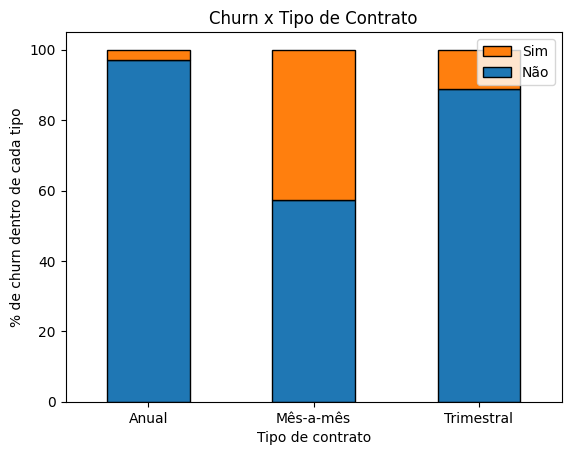

Churn,Não,Sim
Contrato,,
Anual,97.168142,2.831858
Mês-a-mês,57.290323,42.709677
Trimestral,88.730482,11.269518


In [81]:
#Criando a tabela Crosstab
crosstab = pd.crosstab(df["Contrato"], df["Churn"], normalize="index") *100


#Gráfico
grafico = crosstab.plot(kind="bar", stacked=True, ec='k')
plt.title("Churn x Tipo de Contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("% de churn dentro de cada tipo")
plt.xticks(rotation=0)


#Mudando ordem da legenda
handles, labels = plt.gca().get_legend_handles_labels()

#Especificando a ordem
order = [1, 0]

#Refazendo a legenda com a nova ordem
plt.legend([handles[i] for i in order], [labels[i] for i in order])

plt.show()

crosstab



- Esse foi o percentual de empresas que cancelaram o serviço para cada tipo de contrato:
    - Anual: 2,83%
    - Mês-a-mês : 42,7%
    - Trimestral: 11,26%
- Dentre os diferente tipos de contrato, o risco de cancelamento está concentrado no "Mês-a-mês", indicando que a alta fexibilidade de saída é um fator crítico para o churn.

### O churn varia conforme o tempo de relacionamento com a empresa?

### 3.2.7 Churn x Meses de permanência

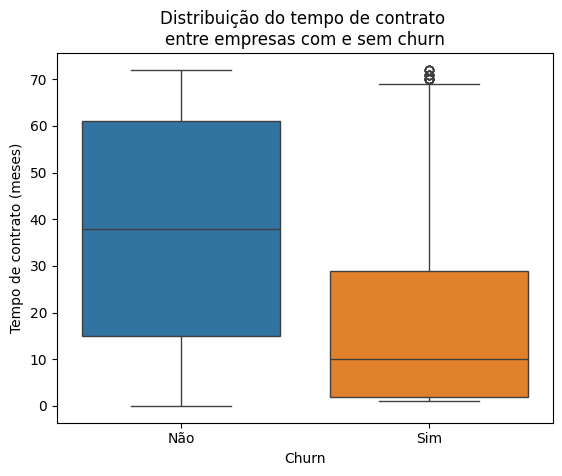

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Não,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Sim,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [82]:
#Gráfico
sns.boxplot(x='Churn', y= 'Meses de permanência',hue='Churn', data=df)
plt.title("Distribuição do tempo de contrato \nentre empresas com e sem churn")
plt.xlabel("Churn")
plt.ylabel("Tempo de contrato (meses)")
plt.show()

#Estatísticas
dados_agrupados = df.groupby("Churn")["Meses de permanência"].describe()
dados_agrupados

- As empresas dentro do grupo que teve Churn tem o tempo de contrato médio de 17,97 meses, menos da metada do tempo médio de contrato daquelas que não cancelaram (37,56 meses).
- Metade das empresas com churn cancelaram o serviço em até 10 meses de contrato.Além disso, 25% delas cancelaram em até 2 meses e 75% em até 29 meses.
- Esses dados indicam que o período inicial de contrato é crucial na retenção dos clientes.

### 3.2.8 Churn x Receita Mensal


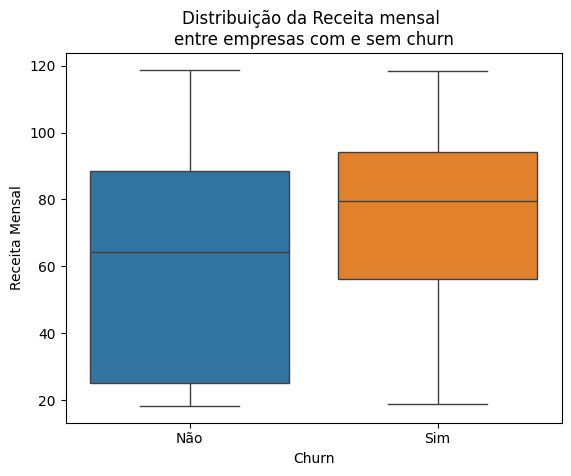

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Não,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Sim,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [83]:
#Gráfico
sns.boxplot(x='Churn', y= 'Receita mensal',hue='Churn', data=df)
plt.title("Distribuição da Receita mensal \nentre empresas com e sem churn")
plt.xlabel("Churn")
plt.ylabel("Receita Mensal")
plt.show()

#Estatísticas
dados_agrupados = df.groupby("Churn")["Receita mensal"].describe()
dados_agrupados

- Clientes que cancelaram o serviço, em média tem receita mensal 74.44 enquanto os que não fizeram churn 61,26.
- 50% dos clientes com churn tem receita maior que 79,65, demonstrando uma concentração nas faixas mais altas de receita.
- 75% dos Churns acontecem com empresas com receita maior que 56.
- Cancelamento está mais concentrado nos clientes com maior receita mensal.

### 3.2.9 Churn x Receita Total

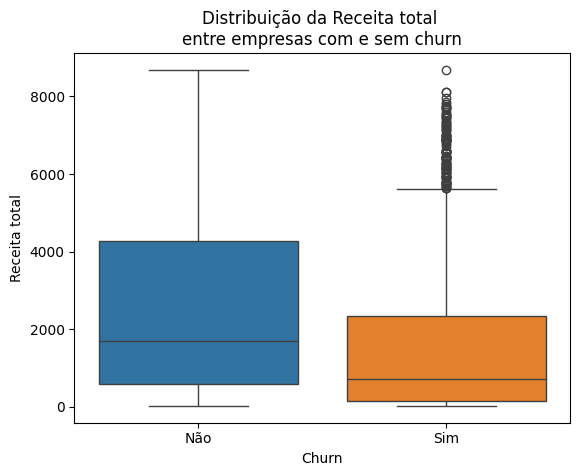

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Não,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
Sim,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


In [84]:
#Gráfico
sns.boxplot(x='Churn', y= 'Receita total',hue='Churn', data=df)
plt.title("Distribuição da Receita total \nentre empresas com e sem churn")
plt.xlabel("Churn")
plt.ylabel("Receita total")
plt.show()

#Estatísticas
dados_agrupados = df.groupby("Churn")["Receita total"].describe()
dados_agrupados

- Em média as empresas que não cancelaram o serviço tem receita total de 2555,34, valor maior que os que cancelaram (1531,79).
- Os dados indicam que as empresas que permaneceram possuem maior receita acumulada.

## 3.3 Correlação

### 3.3.1 Receita mensal X Receita total

,Receita mensal,Receita total
Receita mensal,1.000000,0.651065
Receita total,0.651065,1.000000


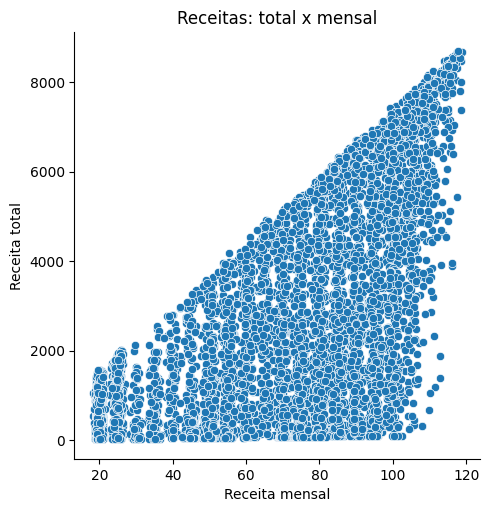

In [85]:
#Gráfico
sns.relplot(data=df,x="Receita mensal",y="Receita total")
plt.title("Receitas: total x mensal")

#Matrix de correlação
df[["Receita mensal","Receita total"]].corr()

- Correlação positiva e alta (0,65). Clientes com maior receita mensal tendem a acumular maior receita ao longo dos anos.
- A correlação não ser perfeita indica que existem outros fatores que estão influenciando, como meses de permanência e o churn.

### 3.3.2 Receita Mensal X Meses de permanência

,Receita mensal,Meses de permanência
Receita mensal,1.0000,0.2479
Meses de permanência,0.2479,1.0000


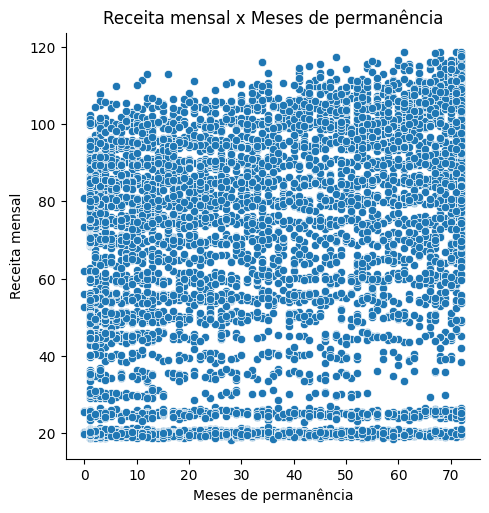

In [86]:
#Gráfico
sns.relplot(data=df,x="Meses de permanência",y="Receita mensal")
plt.title("Receita mensal x Meses de permanência")

#Matrix e correlação
df[["Receita mensal", "Meses de permanência"]].corr()

- Correlação baixa e positiva (0,24). Indicando quase não há relação entre a receita e o tempo de contrato

### 3.3.3 Receita total x Meses de permanência

,Receita total,Meses de permanência
Receita total,1.00000,0.82588
Meses de permanência,0.82588,1.00000


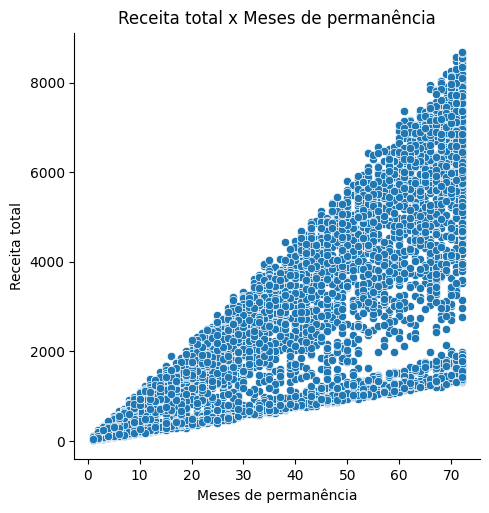

In [87]:
#Gráfico
sns.relplot(data=df,x="Meses de permanência",y="Receita total")
plt.title("Receita total x Meses de permanência")

#Matrix de correlação
df[["Receita total", "Meses de permanência"]].corr()

- Correlação positiva e muito alta (0,82). Indicando que quanto mais tempo de contrato maior a receita acumulada.

### 3.3.4 Mapa de calor das variáveis numéricas

Text(0.5, 1.0, 'Mapa de calor')

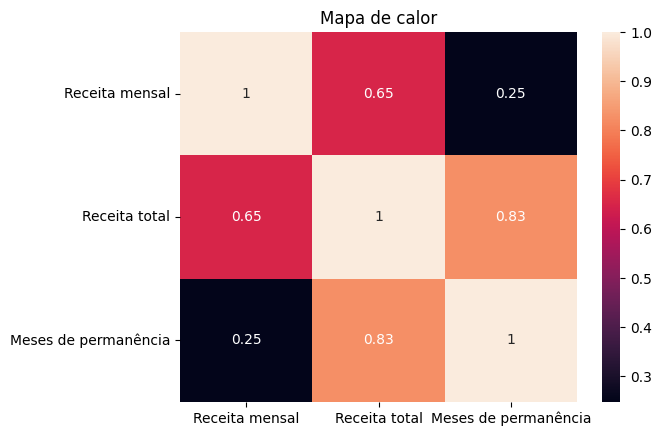

In [88]:
#Matrix de correlação
corr = df[["Receita mensal","Receita total", "Meses de permanência"]].corr()

#Gráfico
sns.heatmap(corr, annot=True)
plt.title("Mapa de calor")

# 4. Conclusões:

- Houve um aumento significativo na taxa de churn nos períodos analisados, de 14,85% em abril para 18,51% em maio. Apesar disso, não é possível confirmar tendência de crescimento pois temos dados de apenas dois meses.

- Clientes com contrato mês-a-mês concentram o maior risco de cancelamento, com churn de 42,7%, contra 11,26% no trimestral e 2,83% no anual. A alta flexibilidade de saída está associada a essa maior taxa de cancelamento.

- O período inicial de contrato é fundamental na retenção de clientes. Dentre os clientes que cancelaram o serviço, 50% deles tiveram até 10 meses de contrato e 25% até 2 meses.

- O uso das funcionalidades está associada ao churn, visto que os clientes com baixo nível de utilização concentram maior número de churns em todos os módulos analisados (entre 33,5% e 41,8%), enquanto os com uso frequente tem taxas significativamente menores.

- Algumas características estruturais se associam ao churn:
    - Entre empresas com até 5 funcionários, 31,3% apresentaram churn, enquanto entre aquelas com 6 ou mais funcionários a taxa foi de 15,5%; de forma semelhante, empresas com apenas um sócio apresentaram cerca de 32,9% de churn, contra aproximadamente 19,4% nas que possuem mais de um.
    - Por outro lado, o porte da empresa não apresentou diferença significativa em relação ao churn, e o ano de fundação indicou apenas uma leve tendência de maior churn em empresas mais antigas, sem associação forte.

- Clientes que cancelaram tinha receita média mensal de 74,44, enquanto os que permaneceram tinham 61,26. Já para receita total o caso foi diferente, os que sairam tinha receita de 1531,79 e os que ficaram 2555,34. Clientes com maior receita total e menor receita mensal tendem a ficar mais tempo.

# 5. Recomendações:

- Desenvolver um dashboard de monitoramento do churn para acompanhar a evolução mensal da taxa e identificar tendências com mais dados.

- Incentivar a migração para planos de maior duração (trimestral e anual), por meio de descontos, campanhas de upgrade e benefícios exclusivos.

- Fortalecer o onboarding nos primeiros meses, com foco em aumentar o engajamento e a adoção do sistema, reduzindo o risco de churn inicial.

-  Aprofundar a análise com testes estatísticos para confirmar se as associações encontradas se sustentam como fatores de risco reais para o churn
